In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

In [3]:
def expandir_contraste(img, L, H):
    """Aplica expansão linear de contraste mapeando [L, H] para [0, 255]."""
    img_float = img.astype(np.float32)
    if H == L:
        return img
    img_exp = (img_float - L) * (255.0 / (H - L))
    img_exp = np.clip(img_exp, 0, 255)
    return img_exp.astype(np.uint8)

def equalizar(img):
    """Aplica equalização de histograma usando OpenCV."""
    return cv2.equalizeHist(img)

def corrigir_gamma(img, gamma):
    """Aplica correção de gamma à imagem."""
    invGamma = 1.0 / gamma
    table = np.array([((i / 255.0) ** invGamma) * 255 for i in np.arange(0, 256)]).astype("uint8")
    return cv2.LUT(img, table)

def plotar_resultados(img_orig, img_proc, titulo_orig, titulo_proc, operacao_nome):
    """Gera o painel 2x2 com Antes/Depois e Histogramas."""
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    # 1. Imagem Original
    axes[0, 0].imshow(img_orig, cmap='gray', vmin=0, vmax=255)
    axes[0, 0].set_title(f"Original: {titulo_orig}")
    axes[0, 0].axis('off')

    # 2. Imagem Processada
    axes[0, 1].imshow(img_proc, cmap='gray', vmin=0, vmax=255)
    axes[0, 1].set_title(f"Processada: {titulo_proc}")
    axes[0, 1].axis('off')

    # 3. Histograma Original
    axes[1, 0].hist(img_orig.ravel(), 256, [0, 256], color='black', alpha=0.7)
    axes[1, 0].set_title("Histograma Original")
    axes[1, 0].set_xlim([0, 256])
    axes[1, 0].set_xlabel("Intensidade do Pixel")
    axes[1, 0].set_ylabel("Frequência")

    # 4. Histograma Processado
    axes[1, 1].hist(img_proc.ravel(), 256, [0, 256], color='blue', alpha=0.7)
    axes[1, 1].set_title(f"Histograma Pós-{operacao_nome}")
    axes[1, 1].set_xlim([0, 256])
    axes[1, 1].set_xlabel("Intensidade do Pixel")

    plt.tight_layout()
    plt.show()

# 1. Imagem Escura

Saving ef4602a6c8ab16159b3df098021bc791.jpg to ef4602a6c8ab16159b3df098021bc791.jpg


/tmp/ipykernel_695/599196206.py:35: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  axes[1, 0].hist(img_orig.ravel(), 256, [0, 256], color='black', alpha=0.7)
/tmp/ipykernel_695/599196206.py:42: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  axes[1, 1].hist(img_proc.ravel(), 256, [0, 256], color='blue', alpha=0.7)


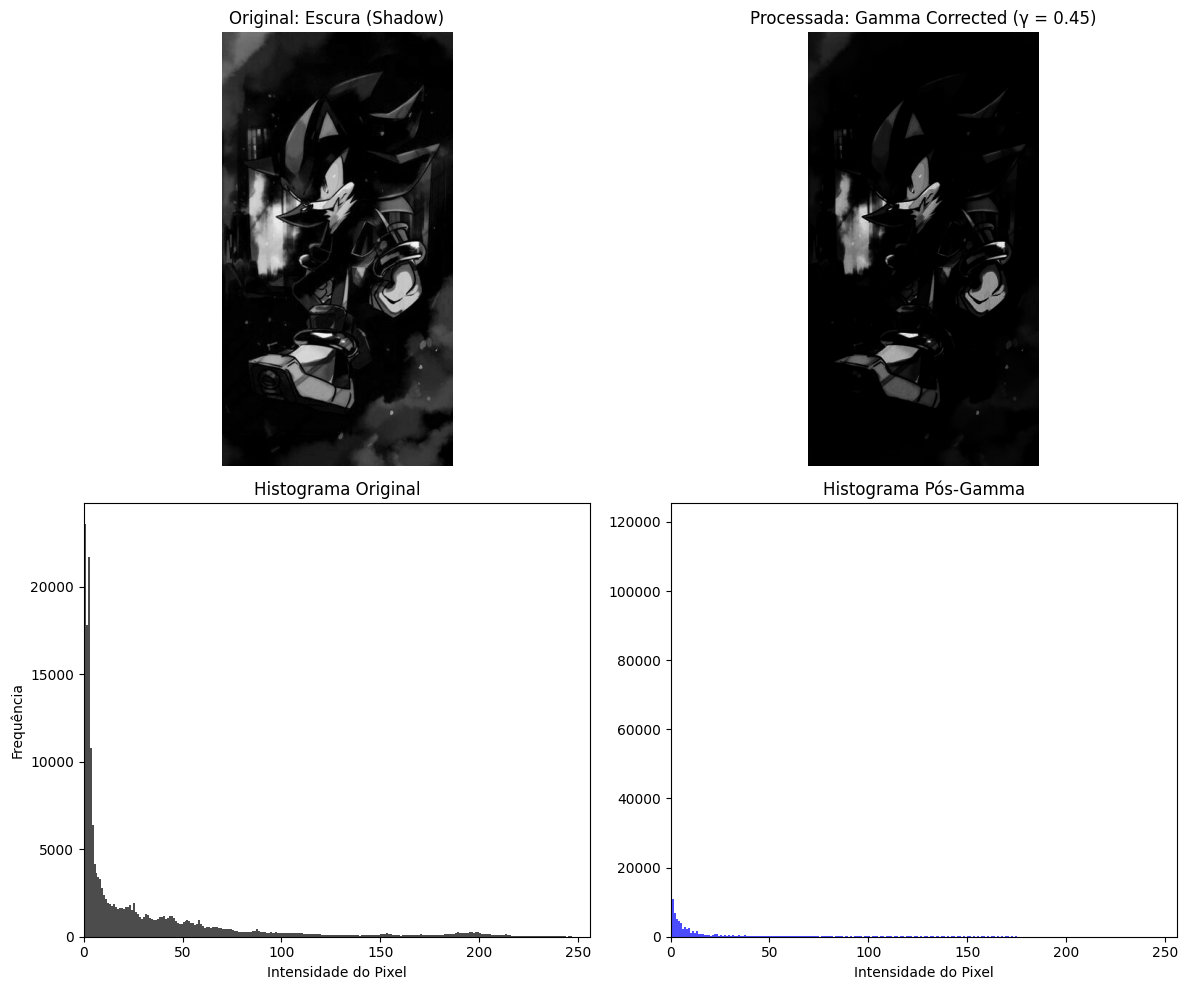

In [4]:
uploaded_escura = files.upload()
path_escura = list(uploaded_escura.keys())[0] # Pega o nome do arquivo enviado dinamicamente

img_escura = cv2.imread(path_escura, cv2.IMREAD_GRAYSCALE)

gamma_escura = 0.45
img_escura_proc = corrigir_gamma(img_escura, gamma=gamma_escura)

plotar_resultados(
    img_escura, img_escura_proc,
    titulo_orig="Escura (Shadow)",
    titulo_proc=f"Gamma Corrected (γ = {gamma_escura})",
    operacao_nome="Gamma"
)

### Diagnóstico:
"As intensidades estão concentradas predominantemente na faixa inferior (0 a 60), indicando uma imagem com subexposição severa."
"Isso faz com que os detalhes nas regiões de sombra e no corpo do personagem fiquem ocultos no preto."

### Operação escolhida:

Correção de Gamma com gamma = 0.45

Justificativa: A correção com gamma < 1 mapeia tons escuros para níveis de cinza mais altos de forma suave, sem estourar o fundo.

# 2. Imagem Clara

Saving if-hyper-forms-were-brought-back-into-the-modern-canon-how-v0-7jcuimxigwsc1.webp to if-hyper-forms-were-brought-back-into-the-modern-canon-how-v0-7jcuimxigwsc1.webp


/tmp/ipykernel_695/599196206.py:35: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  axes[1, 0].hist(img_orig.ravel(), 256, [0, 256], color='black', alpha=0.7)
/tmp/ipykernel_695/599196206.py:42: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  axes[1, 1].hist(img_proc.ravel(), 256, [0, 256], color='blue', alpha=0.7)


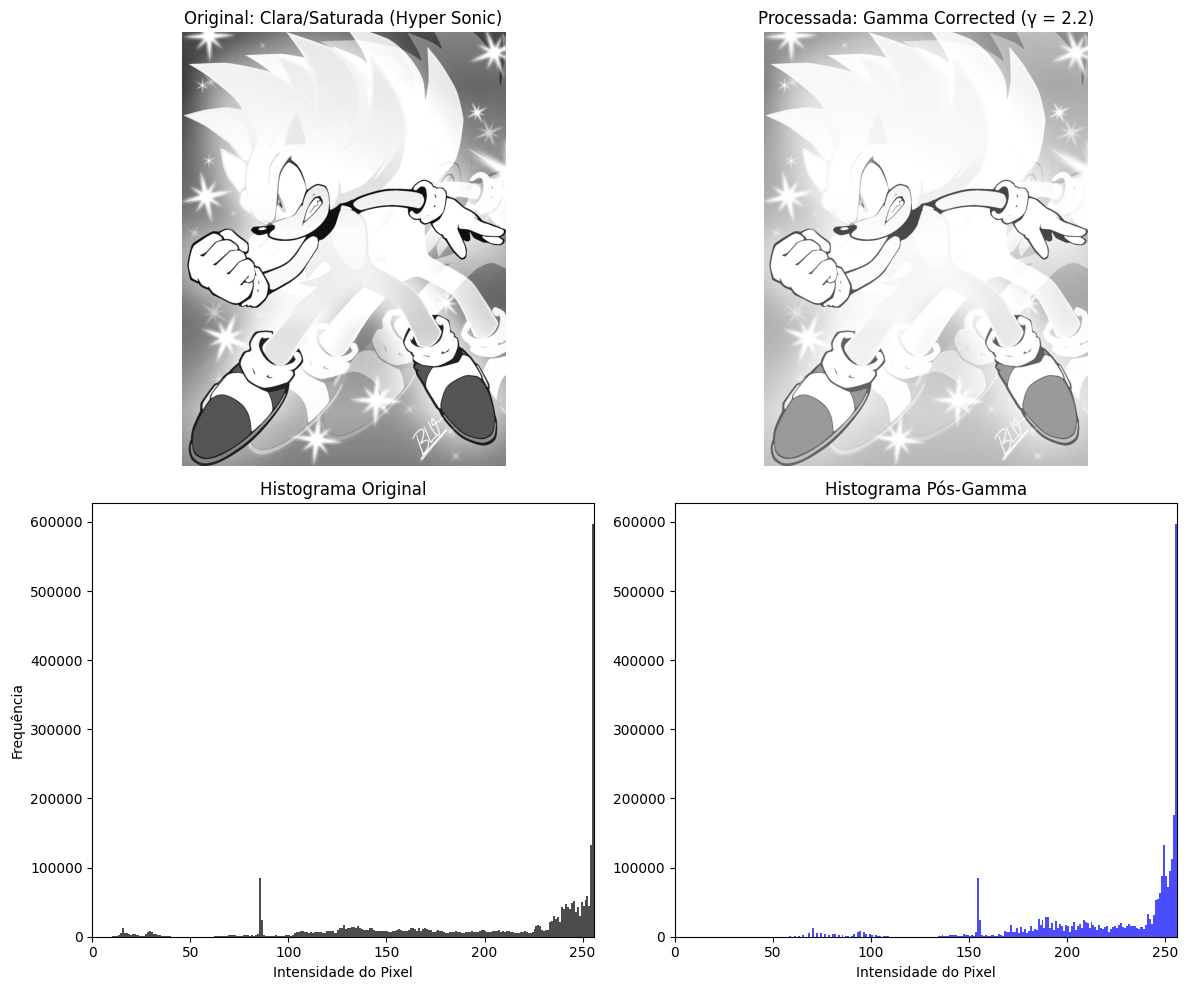

In [5]:
uploaded_clara = files.upload()
path_clara = list(uploaded_clara.keys())[0]

img_clara = cv2.imread(path_clara, cv2.IMREAD_GRAYSCALE)

gamma_clara = 2.2
img_clara_proc = corrigir_gamma(img_clara, gamma=gamma_clara)

plotar_resultados(
    img_clara, img_clara_proc,
    titulo_orig="Clara/Saturada (Hyper Sonic)",
    titulo_proc=f"Gamma Corrected (γ = {gamma_clara})",
    operacao_nome="Gamma"
)

### Diagnóstico:
"As intensidades estão fortemente concentradas na extremidade superior da escala (faixa de 200 a 255), apresentando um pico em 255."
"Isso indica superexposição extrema e saturação de brilho, causando perda de textura no corpo e espinhos do personagem."

###Operação escolhida:
Correção de Gamma com gamma = 2.2

Justificativa: Um gamma > 1 comprime e escurece os valores altos, reduzindo o tom 'lavado' e recuperando os contornos internos.

# 3. Imagem Bem Exposta

Saving 27cc993eb989d86e7a5349846b0e7c8c.jpg to 27cc993eb989d86e7a5349846b0e7c8c.jpg


/tmp/ipykernel_695/599196206.py:35: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  axes[1, 0].hist(img_orig.ravel(), 256, [0, 256], color='black', alpha=0.7)
/tmp/ipykernel_695/599196206.py:42: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  axes[1, 1].hist(img_proc.ravel(), 256, [0, 256], color='blue', alpha=0.7)


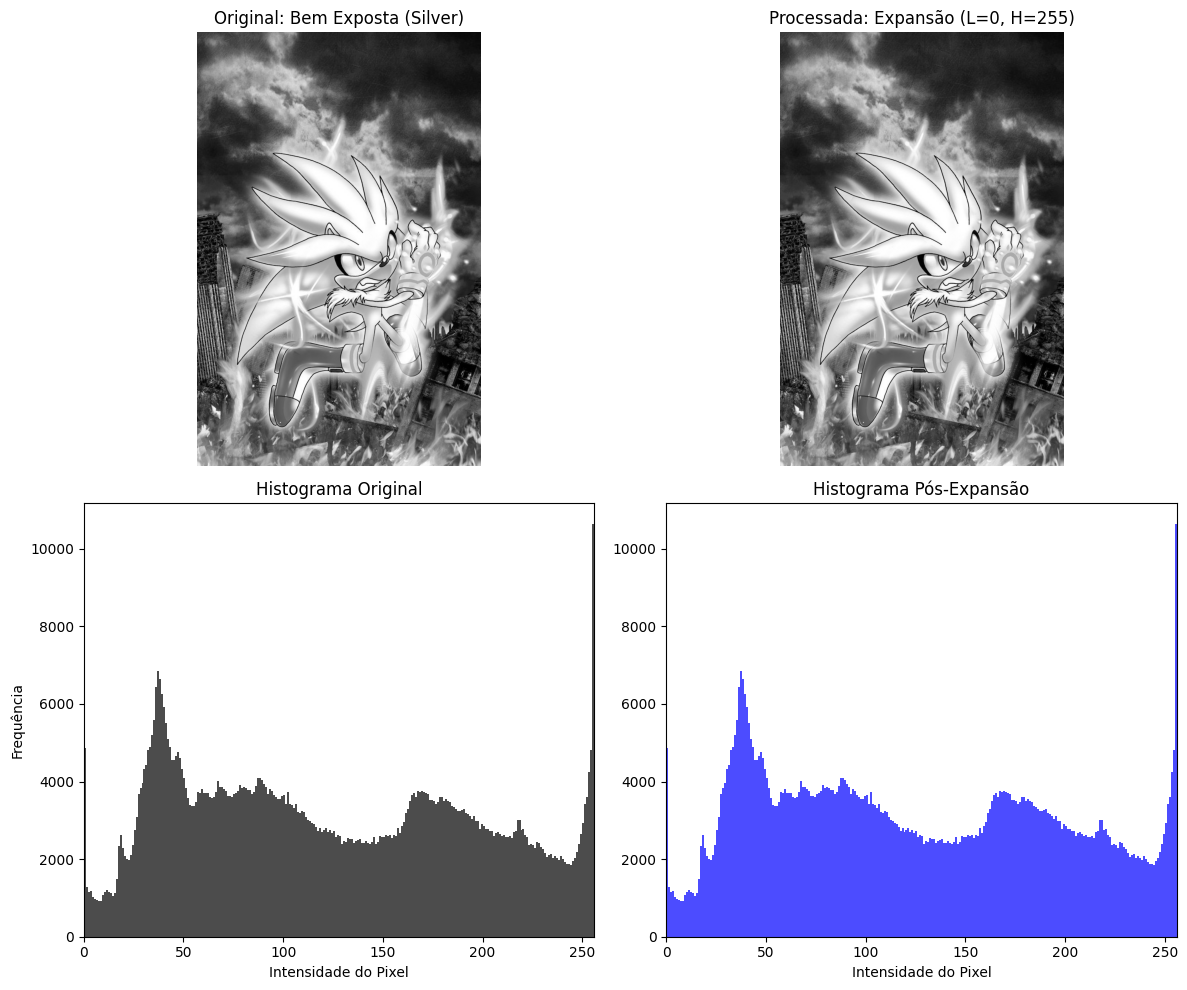

In [7]:
uploaded_exposta = files.upload()
path_exposta = list(uploaded_exposta.keys())[0]

img_exposta = cv2.imread(path_exposta, cv2.IMREAD_GRAYSCALE)

L_val = float(np.min(img_exposta))
H_val = float(np.max(img_exposta))
img_exposta_proc = expandir_contraste(img_exposta, L=L_val, H=H_val)

plotar_resultados(
    img_exposta, img_exposta_proc,
    titulo_orig="Bem Exposta (Silver)",
    titulo_proc=f"Expansão (L={int(L_val)}, H={int(H_val)})",
    operacao_nome="Expansão"
)

### Diagnóstico:
 "As intensidades estão amplamente distribuídas por quase toda a escala de cinza (de 0 a 255), com presença equilibrada de sombras, tons médios e brilhos."
 "Isso indica uma foto com bom alcance dinâmico e alto nível de detalhe preservado em todas as áreas."

### Operação escolhida:

 Expansão de Contraste (Contrast Stretching)

 Justificativa: Utilizou-se os limites mínimos e máximos reais da imagem (L=min, H=max) para testar se havia ganho de alcance dinâmico.

# Em qual das três imagens a operação fez menos diferença? Por quê?

A operação fez menos diferença na terceira imagem (imagem bem exposta - Silver). Isso acontece porque seu histograma original já cobria praticamente todo o alcance dinâmico disponível de níveis de cinza (de 0 a 255). Como a imagem já possuía valores mínimos próximos de 0 e máximos próximos de 255, a aplicação da expansão de contraste (ou qualquer outra transformação linear) mapeia os pixels para valores quase idênticos aos originais, resultando em alterações visuais insignificantes e mantendo a imagem praticamente inalterada em relação ao seu estado inicial.